In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../clean_data/datos_completos.csv', sep=",")

Primero vamos a pasar el único string a minúscula por si acaso en algún año se escribiera diferente.

In [ ]:
df["country or region"] = df["country or region"].str.strip().str.lower()

Vamos a ver la evolución de Finlandia, que es un país que siempre ha estado en el top como hemos visto anteriormente

In [ ]:

finland = df[df["country or region"] == "finland"].sort_values("year")

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(finland["year"], finland["score"], marker="o")

plt.title("Evolución de la felicidad de Finlandia a lo largo de los años")
plt.xlabel("Año")
plt.ylabel("Felicidad")

# astype(str) para evitar que matplotlib muestre los años como float
plt.xticks(finland["year"], finland["year"].astype(str))

plt.grid(True)
plt.show()

Hagamos lo mismo ahora con algún país del top 5 menos felices

In [ ]:
burundi = df[df["country or region"] == "burundi"].sort_values("year")

plt.figure(figsize=(8,5))
plt.plot(burundi["year"], burundi["score"], marker="o")

plt.title("Evolución de la felicidad de Burundi a lo largo de los años")
plt.xlabel("Año")
plt.ylabel("Felicidad")

# astype(str) para evitar que matplotlib muestre los años como float
plt.xticks(burundi["year"], burundi["year"].astype(str))

plt.grid(True)
plt.show()

Aquí vemos un comportamiento interesante, no es una evolución en escalera como Finlandia, aunque el cambio no es muy grande, comprobaremos toda la información para Burundi entre los años 2015 - 2019

In [ ]:
burundi

Vemos que en el año 2019 han disminuido algunas variables pero de entre ellas destacan otras que han aumentado significativamente: healthy life expectancy, freedom to make life choices, perceptions of corruption. Quizás esto estuvo influenciado por algún cambio de gobierno o algún suceso que impactó a esas variables sociales.
Como anteriormente obtuvimos una correlación importante entre -> GDP per Capita y Healthy Life Expectancy vamos a ver en la gráfica la comparativa de estas dos para Finlandia y Burundi

In [ ]:
burundi = df[(df["country or region"] == "burundi") & (df["year"] == 2015)]
finland = df[(df["country or region"] == "finland") & (df["year"] == 2015)]

# Crear gráfico de barras
plt.figure(figsize=(6,5))
plt.bar(
    ["Burundi", "Finlandia"],
    [burundi["gdp per capita"].values[0], finland["gdp per capita"].values[0]],
    color=["red", "green"]
)

plt.title(f"gdp per capita en 2015")
plt.ylabel("gdp per capita")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
burundi = df[(df["country or region"] == "burundi") & (df["year"] == 2015)]
finland = df[(df["country or region"] == "finland") & (df["year"] == 2015)]

# Crear gráfico de barras
plt.figure(figsize=(6,5))
plt.bar(
    ["Burundi", "Finlandia"],
    [burundi["healthy life expectancy"].values[0], finland["healthy life expectancy"].values[0]],
    color=["red", "green"]
)

plt.title(f"healthy life expectancy en 2015")
plt.ylabel("healthy life expectancy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

La diferencia es obvia. Vamos a comprobar la distribución de felicidad para hacernos una idea. Primero para 2015 y luego para 2019

In [ ]:
df_year = df[df["year"] == 2015]

plt.figure(figsize=(8,5))
plt.hist(df_year["score"], bins=10, color="skyblue", edgecolor="black")
plt.title(f"Distribución del Happiness Score de todos los países en 2015")
plt.xlabel("Score")
plt.ylabel("Número de países")
plt.grid(axis="y")
plt.show()

In [ ]:
df_year = df[df["year"] == 2019]

plt.figure(figsize=(8,5))
plt.hist(df_year["score"], bins=10, color="skyblue", edgecolor="black")
plt.title(f"Distribución del Happiness Score de todos los países en 2019")
plt.xlabel("Score")
plt.ylabel("Número de países")
plt.grid(axis="y")
plt.show()

Aunque las distribuciones son muy parecidas entre sí sabemos que en 2019 las puntuaciones se han centrado más en la parte central del histograma, lo que quiere decir que los países con puntuaciones bajas han subido ligeramente y los países con puntuaciones altas han bajado en felicidad.

Por último vamos a comprobar los outliers

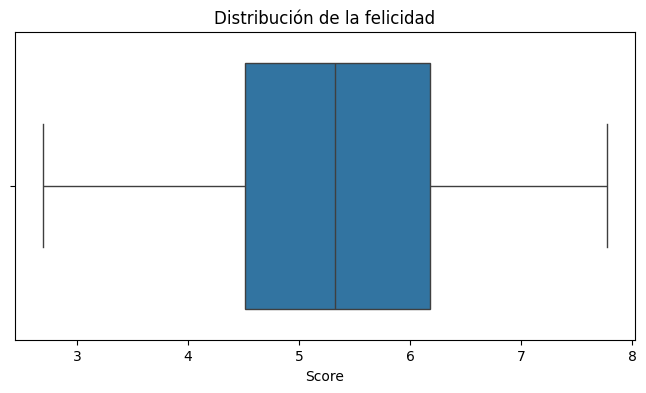

In [53]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["score"])
plt.title("Distribución de la felicidad")
plt.xlabel("Score")
plt.show()

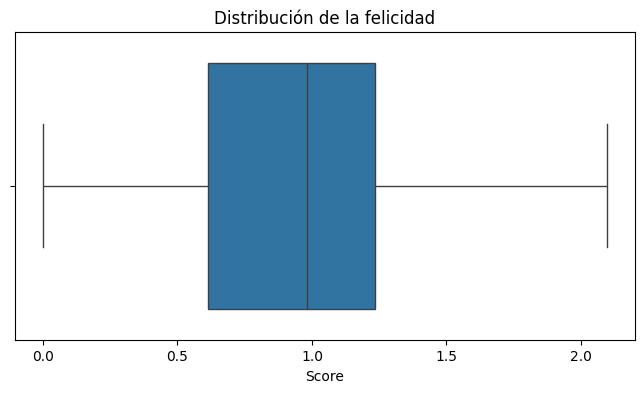

In [54]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["gdp per capita"])
plt.title("Distribución de la felicidad")
plt.xlabel("Score")
plt.show()

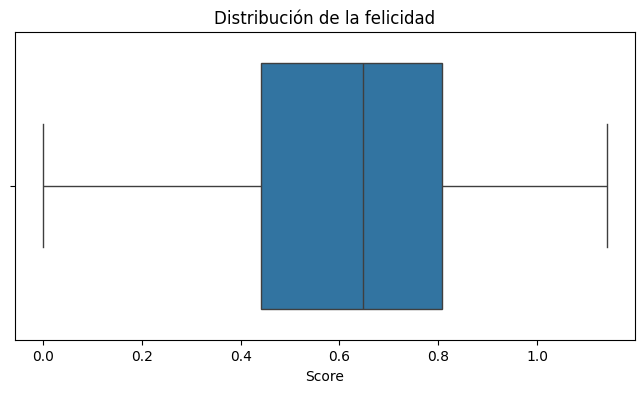

In [55]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["healthy life expectancy"])
plt.title("Distribución de la felicidad")
plt.xlabel("Score")
plt.show()

No se ven valores anómalos dentro de los datos, parecen todos tener coherencia según los valores de sus columnas.